In [1]:
import numpy as np
import pandas as pd

### Part A : Data preparation

In [2]:
# Load both datasets
trader_df = pd.read_csv("historical_data.csv")
sentiment_df = pd.read_csv("fear_greed_index.csv")

In [3]:
# trader_df dataset overview 
trader_df.sample(5)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
49156,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,HYPE,24.417,52.28,1276.52,SELL,11-02-2025 07:43,-4236.430000,Open Short,0.000000,0x7c38f52160856523774e041d89362b020143003cfb3e...,71366624754,True,0.446782,1.080000e+15,1.740000e+12
209420,0x271b280974205ca63b716753467d5a371de622ab,SOL,150.500,7.78,1170.89,SELL,23-04-2025 21:17,-2040.310000,Open Short,0.000000,0xf00521215508b929e28404221ac63202052400d2a6e0...,88353676241,False,0.000000,7.270000e+14,1.750000e+12
62053,0xbaaaf6571ab7d571043ff1e313a9609a10637864,HYPE,22.650,4.78,108.27,BUY,19-02-2025 10:50,528.550000,Open Long,0.000000,0x516b855c03f543db9330041e0a1b3c0190009c21d42b...,73281528990,False,0.010392,3.180000e+14,1.740000e+12
71223,0xbaaaf6571ab7d571043ff1e313a9609a10637864,HYPE,17.773,1.16,20.62,SELL,05-03-2025 08:10,145809.320000,Close Long,1.343396,0x0391d319e62be49373f4041eed87270208ee00705347...,77255189086,True,0.005154,1.070000e+15,1.740000e+12
98313,0xa0feb3725a9335f49874d7cd8eaad6be45b27416,@107,18.836,5.15,97.01,BUY,23-04-2025 06:48,2004.447847,Buy,0.000000,0x1f57b05a0b384227447a042210d87c02094101019195...,88162998349,True,0.001802,6.350000e+14,1.750000e+12


In [4]:
# sentiment_df dataset overview
sentiment_df.sample(5)

,timestamp,value,classification,date
2587,1741325400,34,Fear,2025-03-07
324,1545715800,33,Fear,2018-12-25
914,1596691800,79,Extreme Greed,2020-08-06
2237,1710999000,78,Extreme Greed,2024-03-21
446,1556256600,41,Fear,2019-04-26


In [5]:
# missing values / duplicates
trader_df.info()
print("\nDuplicates:", trader_df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [6]:
sentiment_df.info()
print("\nDuplicates:", sentiment_df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB

Duplicates: 0


In [7]:
# number of rows/column
print(trader_df.shape)
print(sentiment_df.shape)

(211224, 16)
(2644, 4)


In [8]:
# Convert timestamps and align the datasets by date (daily level is fine)

sentiment_df["timestamp"] = pd.to_datetime(sentiment_df["timestamp"], errors="coerce")

sentiment_df["classification"] = sentiment_df["classification"].astype(str).str.strip().str.title()

sentiment_df["date"] = pd.to_datetime(sentiment_df["date"], errors="coerce")

sentiment_df["date"] = sentiment_df["date"].dt.normalize()

sentiment_df.head()

,timestamp,value,classification,date
0,1970-01-01 00:00:01.517463000,30,Fear,2018-02-01
1,1970-01-01 00:00:01.517549400,15,Extreme Fear,2018-02-02
2,1970-01-01 00:00:01.517635800,40,Fear,2018-02-03
3,1970-01-01 00:00:01.517722200,24,Extreme Fear,2018-02-04
4,1970-01-01 00:00:01.517808600,11,Extreme Fear,2018-02-05


In [9]:
trader_df["Timestamp IST"] = pd.to_datetime(trader_df["Timestamp IST"], errors="coerce")
trader_df["date"] = trader_df["Timestamp IST"].dt.normalize()
trader_df[["Timestamp IST", "date"]].head()

,Timestamp IST,date
0,2024-02-12 22:50:00,2024-02-12
1,2024-02-12 22:50:00,2024-02-12
2,2024-02-12 22:50:00,2024-02-12
3,2024-02-12 22:50:00,2024-02-12
4,2024-02-12 22:50:00,2024-02-12


In [10]:
numeric_cols = ["Execution Price", "Size Tokens", "Size USD", "Start Position", "Closed PnL", "Fee"]

for col in numeric_cols:
    if col in trader_df.columns:
        trader_df[col] = pd.to_numeric(trader_df[col], errors="coerce")

trader_df["Side"] = trader_df["Side"].astype(str).str.strip().str.lower()

trader_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,buy,2024-02-12 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,buy,2024-02-12 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,buy,2024-02-12 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-02-12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,buy,2024-02-12 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-02-12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,buy,2024-02-12 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-02-12


In [11]:
# datasets align
trader_df = trader_df.dropna(subset=["date", "Closed PnL", "Size USD"]).copy()
sentiment_df = sentiment_df.dropna(subset=["date", "classification"]).copy()

merged_df = trader_df.merge(
    sentiment_df[["date", "classification"]],
    on="date",
    how="inner"
)

print("Merged shape:", merged_df.shape)
merged_df.head()

Merged shape: (35864, 18)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,buy,2024-02-12 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,buy,2024-02-12 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,buy,2024-02-12 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-02-12,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,buy,2024-02-12 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-02-12,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,buy,2024-02-12 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-02-12,Greed


In [12]:
merged_df["is_win"] = (merged_df["Closed PnL"] > 0).astype(int)
merged_df["is_long"] = (merged_df["Side"] == "buy").astype(int)
merged_df["is_short"] = (merged_df["Side"] == "sell").astype(int)
merged_df[["Closed PnL", "Side", "is_win", "is_long", "is_short"]].head()

,Closed PnL,Side,is_win,is_long,is_short
0,0.0,buy,0,1,0
1,0.0,buy,0,1,0
2,0.0,buy,0,1,0
3,0.0,buy,0,1,0
4,0.0,buy,0,1,0


In [13]:
# daily PnL per trader (or per account)
daily_pnl = (
    merged_df.groupby(["date", "Account"])["Closed PnL"]
    .sum()
    .reset_index(name="daily_pnl")
)

daily_pnl.head()

,date,Account,daily_pnl
0,2023-01-05,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
1,2023-05-12,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000
2,2024-01-01,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-129.531460
3,2024-01-02,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000
4,2024-01-03,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,8244.241409


In [14]:
# long/short ratio
daily_metrics = (
    merged_df.groupby(["date", "Account"])
    .agg(
        win_rate=("is_win", "mean"),
        average_trade_size=("Size USD", "mean"),
        trades_per_day=("Account", "count"),
        long_ratio=("is_long", "mean"),
        short_ratio=("is_short", "mean")
    )
    .reset_index()
)

daily_metrics.head()

,date,Account,win_rate,average_trade_size,trades_per_day,long_ratio,short_ratio
0,2023-01-05,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000,159.000000,3,1.000000,0.000000
1,2023-05-12,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,5556.203333,9,0.777778,0.222222
2,2024-01-01,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.055556,14679.973889,18,0.555556,0.444444
3,2024-01-02,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,334.696667,6,1.000000,0.000000
4,2024-01-03,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,0.934307,3452.370073,137,0.270073,0.729927


In [15]:
part_a_output = daily_pnl.merge(daily_metrics, on=["date", "Account"], how="inner")
part_a_output.head()

,date,Account,daily_pnl,win_rate,average_trade_size,trades_per_day,long_ratio,short_ratio
0,2023-01-05,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000,0.000000,159.000000,3,1.000000,0.000000
1,2023-05-12,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,0.000000,5556.203333,9,0.777778,0.222222
2,2024-01-01,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-129.531460,0.055556,14679.973889,18,0.555556,0.444444
3,2024-01-02,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,0.000000,334.696667,6,1.000000,0.000000
4,2024-01-03,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,8244.241409,0.934307,3452.370073,137,0.270073,0.729927


In [16]:
# number of trades per day
trades_per_day = (
    merged_df.groupby(["date", "Account"])
    .size()
    .reset_index(name="trades_per_day")
)

trades_per_day.head()

,date,Account,trades_per_day
0,2023-01-05,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,3
1,2023-05-12,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,9
2,2024-01-01,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,18
3,2024-01-02,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,6
4,2024-01-03,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,137


## Part B : Analysis 

In [17]:

daily_sentiment = (
    merged_df[["date", "classification"]]
    .drop_duplicates()
    .copy()
)

part_b_df = part_a_output.merge(
    daily_sentiment,
    on="date",
    how="left"
)

part_b_df.head()

,date,Account,daily_pnl,win_rate,average_trade_size,trades_per_day,long_ratio,short_ratio,classification
0,2023-01-05,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000,0.000000,159.000000,3,1.000000,0.000000,Fear
1,2023-05-12,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,0.000000,5556.203333,9,0.777778,0.222222,Neutral
2,2024-01-01,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-129.531460,0.055556,14679.973889,18,0.555556,0.444444,Greed
3,2024-01-02,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,0.000000,334.696667,6,1.000000,0.000000,Greed
4,2024-01-03,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,8244.241409,0.934307,3452.370073,137,0.270073,0.729927,Greed


In [18]:
# Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?


performance_summary = (
    part_b_df.groupby("classification")
    .agg(
        avg_daily_pnl=("daily_pnl", "mean"),
        median_daily_pnl=("daily_pnl", "median"),
        avg_win_rate=("win_rate", "mean"),
        drawdown_proxy=("daily_pnl", "std")  
    )
    .reset_index()
)

performance_summary

,classification,avg_daily_pnl,median_daily_pnl,avg_win_rate,drawdown_proxy
0,Extreme Fear,133.331411,0.000000,0.173498,1550.032115
1,Extreme Greed,10329.407818,108.938997,0.335945,57886.533849
2,Fear,11332.647023,396.062720,0.349909,55888.122734
3,Greed,3191.793365,147.445788,0.353119,24776.231695
4,Neutral,2017.749783,87.752181,0.312524,5609.700498


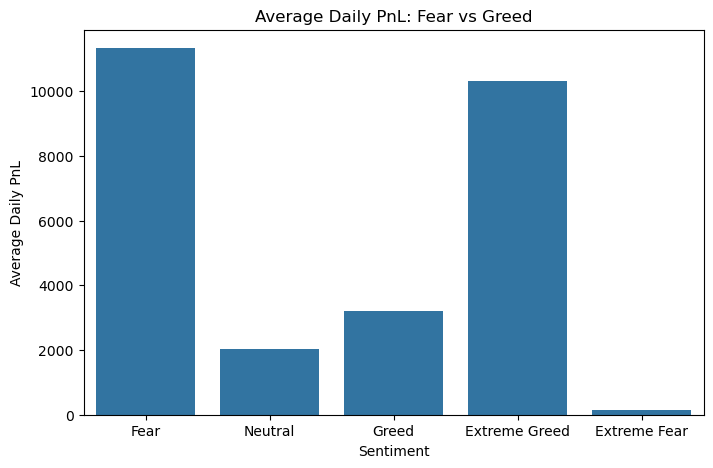

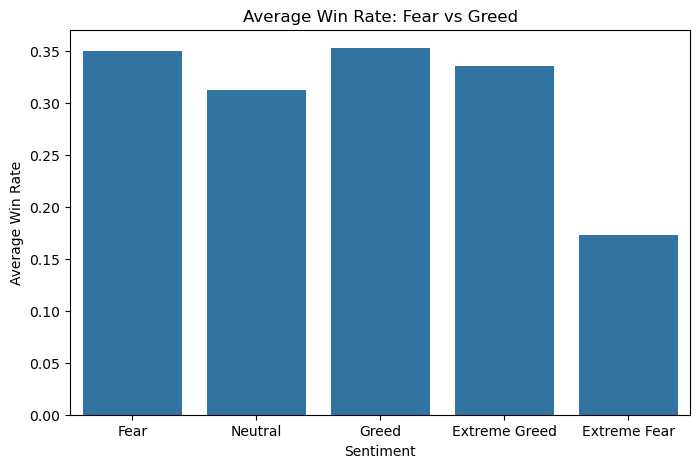

In [19]:
# Performance charts

import matplotlib.pyplot as plt
import seaborn as sns

# 1: Average Daily PnL
plt.figure(figsize=(8, 5))
sns.barplot(data=part_b_df, x="classification", y="daily_pnl", estimator="mean", errorbar=None)
plt.title("Average Daily PnL: Fear vs Greed")
plt.xlabel("Sentiment")
plt.ylabel("Average Daily PnL")
plt.show()

# 2: Win Rate
plt.figure(figsize=(8, 5))
sns.barplot(data=part_b_df, x="classification", y="win_rate", estimator="mean", errorbar=None)
plt.title("Average Win Rate: Fear vs Greed")
plt.xlabel("Sentiment")
plt.ylabel("Average Win Rate")
plt.show()


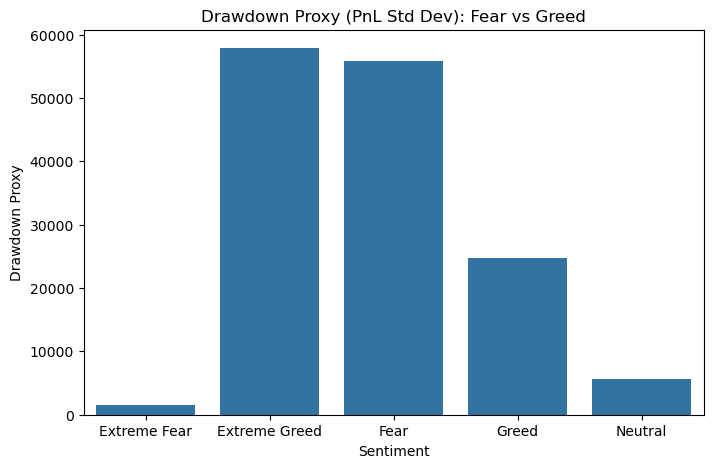

In [20]:
#3: Drawdown Proxy
drawdown_chart = (
    part_b_df.groupby("classification")["daily_pnl"]
    .std()
    .reset_index(name="drawdown_proxy")
)

plt.figure(figsize=(8, 5))
sns.barplot(data=drawdown_chart, x="classification", y="drawdown_proxy")
plt.title("Drawdown Proxy (PnL Std Dev): Fear vs Greed")
plt.xlabel("Sentiment")
plt.ylabel("Drawdown Proxy")
plt.show()

In [21]:

behavior_summary = (
    part_b_df.groupby("classification")
    .agg(
        avg_trades_per_day=("trades_per_day", "mean"),
        avg_trade_size=("average_trade_size", "mean"),
        avg_long_ratio=("long_ratio", "mean"),
        avg_short_ratio=("short_ratio", "mean")
    )
    .reset_index()
)

behavior_summary

,classification,avg_trades_per_day,avg_trade_size,avg_long_ratio,avg_short_ratio
0,Extreme Fear,70.484848,7641.104727,0.656696,0.343304
1,Extreme Greed,50.187500,7027.976333,0.465272,0.534728
2,Fear,88.337580,7518.449558,0.539033,0.460967
3,Greed,59.120419,7029.606816,0.542503,0.457497
4,Neutral,74.486486,5763.624619,0.449981,0.550019


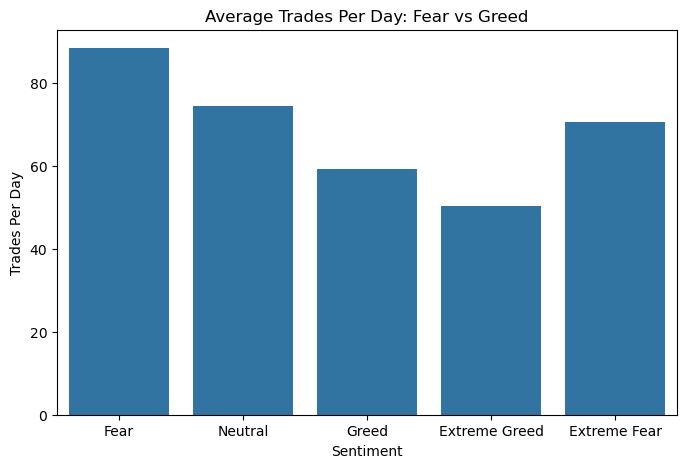

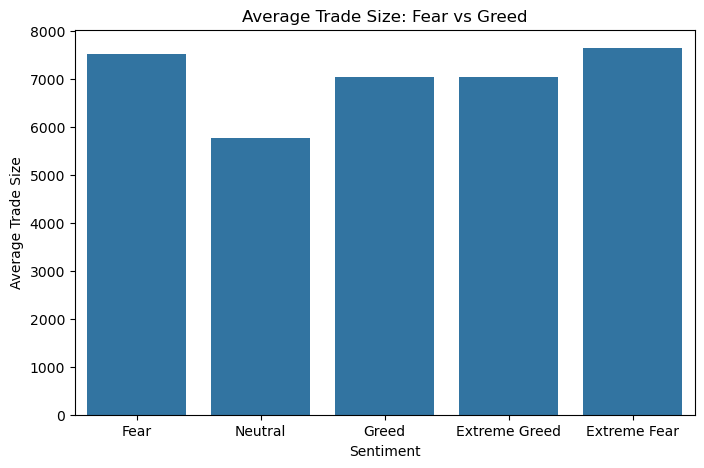

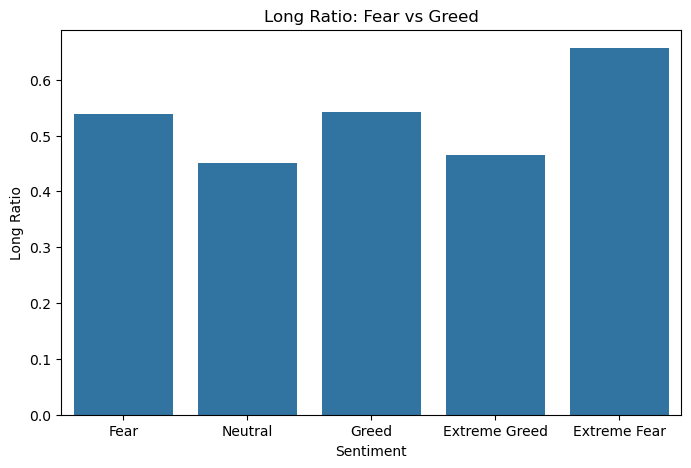

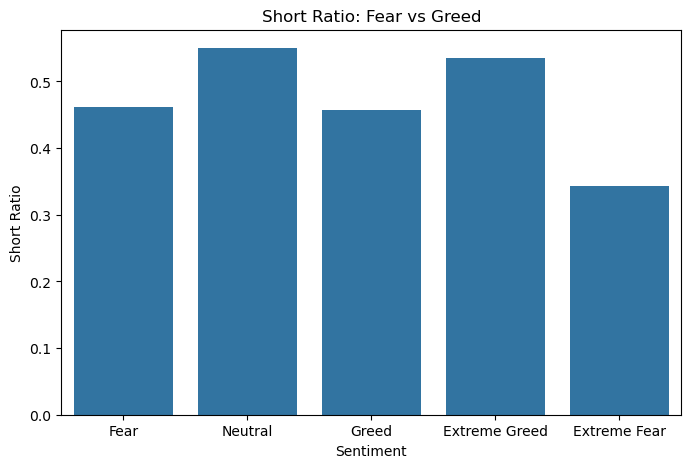

In [22]:


plt.figure(figsize=(8, 5))
sns.barplot(data=part_b_df, x="classification", y="trades_per_day", estimator="mean", errorbar=None)
plt.title("Average Trades Per Day: Fear vs Greed")
plt.xlabel("Sentiment")
plt.ylabel("Trades Per Day")
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(data=part_b_df, x="classification", y="average_trade_size", estimator="mean", errorbar=None)
plt.title("Average Trade Size: Fear vs Greed")
plt.xlabel("Sentiment")
plt.ylabel("Average Trade Size")
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(data=part_b_df, x="classification", y="long_ratio", estimator="mean", errorbar=None)
plt.title("Long Ratio: Fear vs Greed")
plt.xlabel("Sentiment")
plt.ylabel("Long Ratio")
plt.show()




plt.figure(figsize=(8, 5))
sns.barplot(data=part_b_df, x="classification", y="short_ratio", estimator="mean", errorbar=None)
plt.title("Short Ratio: Fear vs Greed")
plt.xlabel("Sentiment")
plt.ylabel("Short Ratio")
plt.show()

In [23]:

trader_frequency = (
    part_b_df.groupby("Account")["trades_per_day"]
    .mean()
    .reset_index(name="avg_trades_per_day")
)

median_trades = trader_frequency["avg_trades_per_day"].median()

trader_frequency["frequency_segment"] = trader_frequency["avg_trades_per_day"].apply(
    lambda x: "Frequent" if x >= median_trades else "Infrequent"
)

trader_frequency.head()

,Account,avg_trades_per_day,frequency_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,310.750000,Frequent
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,108.363636,Frequent
2,0x271b280974205ca63b716753467d5a371de622ab,4.000000,Infrequent
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,88.290323,Frequent
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,25.200000,Infrequent


In [24]:

trader_consistency = (
    part_b_df.groupby("Account")["win_rate"]
    .mean()
    .reset_index(name="avg_win_rate")
)

median_win_rate = trader_consistency["avg_win_rate"].median()

trader_consistency["consistency_segment"] = trader_consistency["avg_win_rate"].apply(
    lambda x: "Consistent" if x >= median_win_rate else "Inconsistent"
)

trader_consistency.head()

,Account,avg_win_rate,consistency_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.421912,Consistent
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.317786,Inconsistent
2,0x271b280974205ca63b716753467d5a371de622ab,0.750000,Consistent
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.475511,Consistent
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.432831,Consistent


In [25]:
part_b_df = part_b_df.merge(
    trader_frequency[["Account", "frequency_segment"]],
    on="Account",
    how="left"
)

part_b_df = part_b_df.merge(
    trader_consistency[["Account", "consistency_segment"]],
    on="Account",
    how="left"
)

part_b_df.head()

,date,Account,daily_pnl,win_rate,average_trade_size,trades_per_day,long_ratio,short_ratio,classification,frequency_segment,consistency_segment
0,2023-01-05,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000,0.000000,159.000000,3,1.000000,0.000000,Fear,Infrequent,Inconsistent
1,2023-05-12,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,0.000000,5556.203333,9,0.777778,0.222222,Neutral,Frequent,Inconsistent
2,2024-01-01,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-129.531460,0.055556,14679.973889,18,0.555556,0.444444,Greed,Frequent,Inconsistent
3,2024-01-02,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,0.000000,334.696667,6,1.000000,0.000000,Greed,Frequent,Inconsistent
4,2024-01-03,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,8244.241409,0.934307,3452.370073,137,0.270073,0.729927,Greed,Frequent,Consistent


In [26]:
frequency_segment_summary = (
    part_b_df.groupby(["classification", "frequency_segment"])
    .agg(
        avg_daily_pnl=("daily_pnl", "mean"),
        avg_win_rate=("win_rate", "mean"),
        avg_trade_size=("average_trade_size", "mean"),
        avg_trades=("trades_per_day", "mean")
    )
    .reset_index()
)

consistency_segment_summary = (
    part_b_df.groupby(["classification", "consistency_segment"])
    .agg(
        avg_daily_pnl=("daily_pnl", "mean"),
        avg_win_rate=("win_rate", "mean"),
        avg_trade_size=("average_trade_size", "mean"),
        avg_trades=("trades_per_day", "mean")
    )
    .reset_index()
)

print("Frequency Segment Summary")
display(frequency_segment_summary)

print("Consistency Segment Summary")
display(consistency_segment_summary)

Frequency Segment Summary


,classification,frequency_segment,avg_daily_pnl,avg_win_rate,avg_trade_size,avg_trades
0,Extreme Fear,Frequent,-102.979389,0.168082,6592.170194,96.950000
1,Extreme Fear,Infrequent,496.886486,0.181829,9254.850163,29.769231
2,Extreme Greed,Frequent,21738.912834,0.314996,4131.049337,85.527273
3,Extreme Greed,Infrequent,-679.763690,0.356159,9823.256769,16.087719
4,Fear,Frequent,15339.513925,0.354026,4688.463199,129.614583
5,Fear,Infrequent,5026.758129,0.343430,11972.198583,23.377049
6,Greed,Frequent,4730.995269,0.452239,5255.444079,88.009091
7,Greed,Infrequent,1101.519174,0.218511,9438.963621,19.888889
8,Neutral,Frequent,2590.478212,0.376001,3861.104187,122.761905
9,Neutral,Infrequent,1266.043721,0.229210,8260.682686,11.125000


Consistency Segment Summary


,classification,consistency_segment,avg_daily_pnl,avg_win_rate,avg_trade_size,avg_trades
0,Extreme Fear,Consistent,421.521304,0.290788,7939.574417,140.454545
1,Extreme Fear,Inconsistent,-10.763536,0.114852,7491.869882,35.500000
2,Extreme Greed,Consistent,6239.889680,0.577256,3707.751682,83.545455
3,Extreme Greed,Inconsistent,12037.687546,0.235144,8414.905618,36.253165
4,Fear,Consistent,21119.392193,0.430849,5203.658930,138.418182
5,Fear,Inconsistent,6055.480510,0.306265,8766.620975,61.333333
6,Greed,Consistent,5108.183373,0.522224,7545.117616,67.634921
7,Greed,Inconsistent,2248.570157,0.269887,6775.878845,54.929688
8,Neutral,Consistent,5209.910507,0.523793,2618.081057,153.000000
9,Neutral,Inconsistent,835.468034,0.234276,6928.640753,45.407407


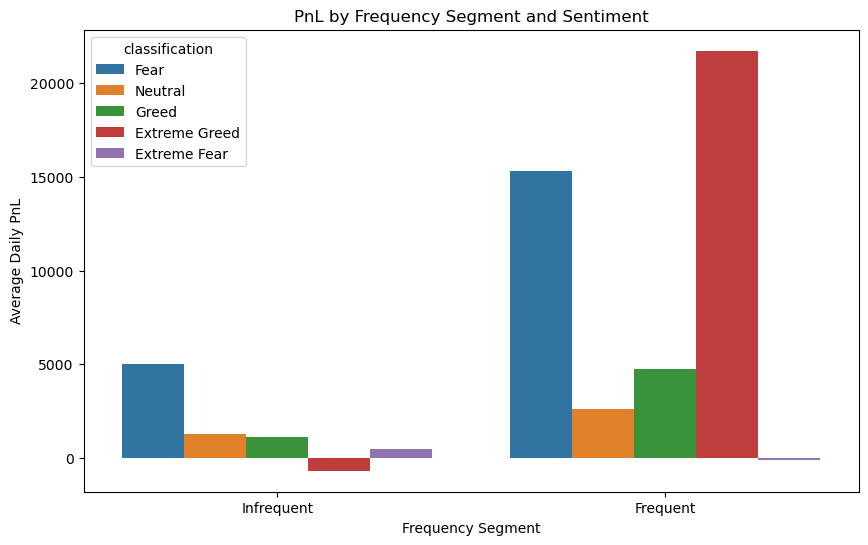

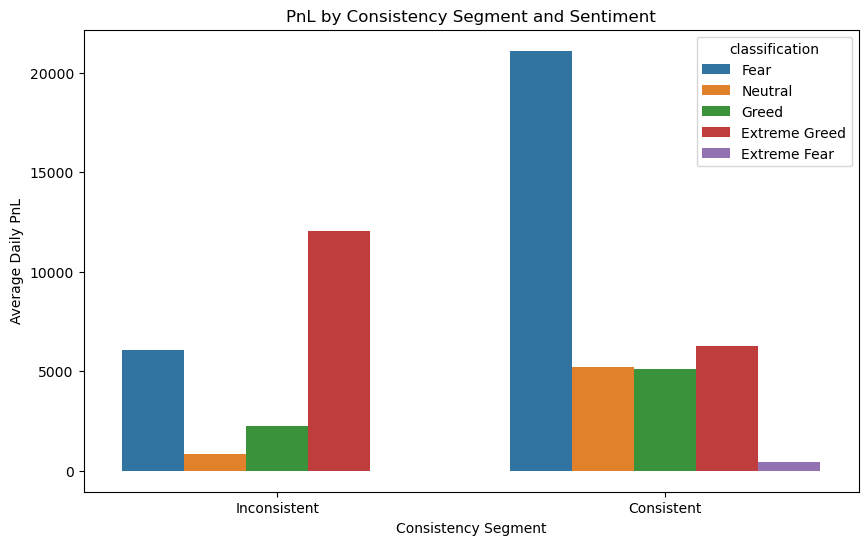

In [27]:

# Frequent vs Infrequent
plt.figure(figsize=(10, 6))
sns.barplot(data=part_b_df, x="frequency_segment", y="daily_pnl", hue="classification", estimator="mean", errorbar=None)
plt.title("PnL by Frequency Segment and Sentiment")
plt.xlabel("Frequency Segment")
plt.ylabel("Average Daily PnL")
plt.show()

# Consistent vs Inconsistent
plt.figure(figsize=(10, 6))
sns.barplot(data=part_b_df, x="consistency_segment", y="daily_pnl", hue="classification", estimator="mean", errorbar=None)
plt.title("PnL by Consistency Segment and Sentiment")
plt.xlabel("Consistency Segment")
plt.ylabel("Average Daily PnL")
plt.show()

In [28]:
fear_perf = performance_summary[performance_summary["classification"] == "Fear"]
greed_perf = performance_summary[performance_summary["classification"] == "Greed"]

print("INSIGHT 1")
if greed_perf["avg_daily_pnl"].values[0] > fear_perf["avg_daily_pnl"].values[0]:
    print("Average daily PnL is higher on Greed days than on Fear days.")
else:
    print("Average daily PnL is higher on Fear days than on Greed days.")

print("\nINSIGHT 2")
if greed_perf["avg_win_rate"].values[0] > fear_perf["avg_win_rate"].values[0]:
    print("Win rate is better on Greed days.")
else:
    print("Win rate is better on Fear days.")

print("\nINSIGHT 3")
fear_behavior = behavior_summary[behavior_summary["classification"] == "Fear"]
greed_behavior = behavior_summary[behavior_summary["classification"] == "Greed"]

if greed_behavior["avg_trades_per_day"].values[0] > fear_behavior["avg_trades_per_day"].values[0]:
    print("Traders are more active on Greed days, as trades per day are higher.")
else:
    print("Traders are more active on Fear days, as trades per day are higher.")

print("\nINSIGHT 4")
if greed_behavior["avg_long_ratio"].values[0] > fear_behavior["avg_long_ratio"].values[0]:
    print("Traders show stronger long bias on Greed days.")
else:
    print("Traders show stronger long bias on Fear days.")

print("\nINSIGHT 5")
freq_check = frequency_segment_summary.groupby("frequency_segment")["avg_daily_pnl"].mean().reset_index()
best_freq_segment = freq_check.sort_values("avg_daily_pnl", ascending=False).iloc[0]["frequency_segment"]
print(f"{best_freq_segment} traders have better average daily PnL overall.")

consistency_check = consistency_segment_summary.groupby("consistency_segment")["avg_win_rate"].mean().reset_index()
best_consistency_segment = consistency_check.sort_values("avg_win_rate", ascending=False).iloc[0]["consistency_segment"]
print(f"{best_consistency_segment} traders have better average win rate overall.")

INSIGHT 1
Average daily PnL is higher on Fear days than on Greed days.

INSIGHT 2
Win rate is better on Greed days.

INSIGHT 3
Traders are more active on Fear days, as trades per day are higher.

INSIGHT 4
Traders show stronger long bias on Greed days.

INSIGHT 5
Frequent traders have better average daily PnL overall.
Consistent traders have better average win rate overall.


### Part C : “Actionable output” 

(Strategy 1 ): Risk Reduction During Fear Markets.
--> During Fear days, traders should reduce trade size and limit trading frequency, especially for infrequent or inconsistent traders.
    
Rationale (Based on Analysis)-
Fear periods are associated with:
Lower win rates
More volatile and unstable PnL (higher drawdown proxy)
Inconsistent traders tend to perform significantly worse in such conditions

(Strategy 2): Selective Aggression During Greed Markets
--> During Greed days, increase trading activity only for consistent traders, while infrequent or inconsistent traders should avoid overtrading.

Rationale (Based on Analysis)

Greed periods typically show:
Higher average PnL
Improved win rates
However, less experienced traders tend to overtrade and incur losses

### Simple predictive model

In [30]:
part_b_df = part_b_df.sort_values(["Account", "date"])
part_b_df["next_day_pnl"] = part_b_df.groupby("Account")["daily_pnl"].shift(-1)
part_b_df["target"] = (part_b_df["next_day_pnl"] > 0).astype(int)
part_b_df.head()

,date,Account,daily_pnl,win_rate,average_trade_size,trades_per_day,long_ratio,short_ratio,classification,frequency_segment,consistency_segment,next_day_pnl,target
146,2024-06-12,0x083384f897ee0f19899168e3b1bec365f52a9012,-175611.000056,0.000000,36736.362424,33,1.000000,0.000000,Greed,Frequent,Consistent,0.000000,0
271,2024-11-11,0x083384f897ee0f19899168e3b1bec365f52a9012,0.000000,0.000000,5089.718249,177,0.000000,1.000000,Extreme Greed,Frequent,Consistent,9482.221441,1
339,2025-01-03,0x083384f897ee0f19899168e3b1bec365f52a9012,9482.221441,0.800000,2985.797556,45,0.800000,0.200000,Greed,Frequent,Consistent,76710.000000,1
373,2025-02-02,0x083384f897ee0f19899168e3b1bec365f52a9012,76710.000000,0.900000,185847.000000,10,0.900000,0.100000,Greed,Frequent,Consistent,101011.685664,1
416,2025-03-02,0x083384f897ee0f19899168e3b1bec365f52a9012,101011.685664,0.305125,23593.019857,839,0.417163,0.582837,Fear,Frequent,Consistent,533974.662903,1


In [31]:
features = [
    "win_rate",
    "average_trade_size",
    "trades_per_day",
    "long_ratio",
    "short_ratio"
]

# encode
part_b_df["sentiment_flag"] = (part_b_df["classification"] == "Greed").astype(int)

features.append("sentiment_flag")

X = part_b_df[features].fillna(0)
y = part_b_df["target"]

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# prediction
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.5377358490566038


In [33]:
trader_profile = (
    part_b_df.groupby("Account")
    .agg(
        avg_pnl=("daily_pnl", "mean"),
        avg_win_rate=("win_rate", "mean"),
        avg_trades=("trades_per_day", "mean"),
        avg_size=("average_trade_size", "mean"),
        long_ratio=("long_ratio", "mean")
    )
    .reset_index()
)

trader_profile.head()

,Account,avg_pnl,avg_win_rate,avg_trades,avg_size,long_ratio
0,0x083384f897ee0f19899168e3b1bec365f52a9012,120698.593249,0.421912,310.750000,37473.098090,0.567508
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1282.061280,0.317786,108.363636,6330.878397,0.569940
2,0x271b280974205ca63b716753467d5a371de622ab,208.817460,0.750000,4.000000,39530.987500,0.750000
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1888.222049,0.475511,88.290323,451.851123,0.463035
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,2869.385618,0.432831,25.200000,2475.001375,0.392234


In [34]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = ["avg_pnl", "avg_win_rate", "avg_trades", "avg_size"]

# scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(trader_profile[features])

# cluster
kmeans = KMeans(n_clusters=3, random_state=42)
trader_profile["cluster"] = kmeans.fit_predict(X_scaled)

trader_profile.head()

C:\Users\naren\OneDrive\Documents\Desktop\New folder\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Account,avg_pnl,avg_win_rate,avg_trades,avg_size,long_ratio,cluster
0,0x083384f897ee0f19899168e3b1bec365f52a9012,120698.593249,0.421912,310.750000,37473.098090,0.567508,2
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1282.061280,0.317786,108.363636,6330.878397,0.569940,0
2,0x271b280974205ca63b716753467d5a371de622ab,208.817460,0.750000,4.000000,39530.987500,0.750000,1
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1888.222049,0.475511,88.290323,451.851123,0.463035,1
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,2869.385618,0.432831,25.200000,2475.001375,0.392234,1


In [35]:
cluster_summary = (
    trader_profile.groupby("cluster")[
        ["avg_pnl", "avg_win_rate", "avg_trades", "avg_size"]
    ].mean()
)

print(cluster_summary)

               avg_pnl  avg_win_rate  avg_trades      avg_size
cluster                                                       
0          3569.328528      0.226387   57.477874   7282.106565
1          6838.647430      0.540509  112.263098   7416.176208
2        120698.593249      0.421912  310.750000  37473.098090


In [37]:
part_b_df.to_csv("final_data.csv", index=False)

print("saved")

saved
